In [39]:
import imageio.v3 as iio

%load_ext autoreload
%autoreload 2

import os
from torch.utils.data import Dataset
import glob
import logging
from torchvision import transforms
from typing import Tuple
from bidr_relight.image_process import normalized_linear_to_srgb


logging.basicConfig(
    level=logging.INFO, format="[%(asctime)s] [%(levelname)s] %(message)s"
)
logger = logging.getLogger(__name__)


class LinearImageDataset(Dataset):
    def __init__(self, dir, format="tiff", resize: Tuple[int, int] = None):
        self.dir = dir
        self.imgs = glob.glob(os.path.join(self.dir, f"*.{format}"))
        self.num_imgs = len(self.imgs)

        self.resize = None
        if resize:
            self.resize = transforms.Resize(resize)

        logger.info(f"Found {self.num_imgs} images in {self.dir}")

    def __len__(self):
        return self.num_imgs

    def __getitem__(self, idx):
        img = iio.imread(self.imgs[idx])
        return img

    def get_linear(self, idx):
        pass

    def get_log(self, idx):
        pass

    def visualize(self, idx):
        pass


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
ds = LinearImageDataset(dir="../data/RAWAE")
print(ds.imgs)

[2025-12-08 20:18:13,655] [INFO] Found 6 images in ../data/RAWAE


['../data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff', '../data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff', '../data/RAWAE/raw_maxwell_2023_05_26_ - 000684.tiff', '../data/RAWAE/raw_maxwell_2023_05_26_ - 001133.tiff', '../data/RAWAE/raw_maxwell_2023_05_26_ - 001026.tiff', '../data/RAWAE/raw_maxwell_2023_05_26_ - 001123.tiff']


In [41]:
import numpy as np
import plotly.graph_objects as go


def plot_interactive_logrgb(
    img,
    N=100000,
    bit_depth=16,
    title="3D RGB Scatter Plot (log-scaled positions, original colors)",
):
    """
    Create a 3D scatter plot of an RGB image using log-scaled positions and original colors.

    Args:
        img: np.ndarray, shape (H, W, 3), linear RGB image
        N: int, max number of points to subsample
        bit_depth: int, bit depth of image (default 16)
        title: str, plot title
    """
    # Flatten channels
    img_flat = img.reshape(-1, 3)

    # Convert to sRGB colors – assumed normalized in [0,1]
    color = normalized_linear_to_srgb(img / (2**bit_depth - 1))
    color_flat = np.clip(color.reshape(-1, 3), 0, 255).astype(np.uint8)

    # Subsample for performance
    if len(img_flat) > N:
        idx = np.random.choice(len(img_flat), N, replace=False)
        img_sampled = img_flat[idx]
        color_sampled = color_flat[idx]
    else:
        img_sampled = img_flat
        color_sampled = color_flat

    # Build Plotly color strings
    colors = [f"rgb({c[0]},{c[1]},{c[2]})" for c in color_sampled]

    # Log positions (avoid log(0))
    log_img = np.log(img_sampled + 1e-6)

    # 3D scatter plot
    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=log_img[:, 0],
                y=log_img[:, 1],
                z=log_img[:, 2],
                mode="markers",
                marker=dict(
                    size=2,
                    color=colors,
                    opacity=1.0,
                ),
            )
        ]
    )

    fig.update_layout(
        scene=dict(
            xaxis_title="log(Red)",
            yaxis_title="log(Green)",
            zaxis_title="log(Blue)",
        ),
        title=title,
    )

    fig.show()


In [37]:
img_idx = 1
img = ds[img_idx].astype(np.float32)
print(img.shape, img.min(), img.max())

plot_interactive_logrgb(img, N=5000)

(2348, 3522, 3) 422.0 65535.0
18


In [8]:
import numpy as np
import matplotlib.pyplot as plt


def show_linear_image(img, gamma=1 / 2.2):
    """
    Display a 16-bit linear RGB image using matplotlib."

    Args:
        img_path (str): Path to the 16-bit image (TIFF, linear RGB).
        gamma (float): Optional gamma correction for visualization.
    """
    # Load 16-bit image
    img = img.astype(np.float32)

    # Normalize 0-1 based on 16-bit range
    img_norm = img / 65535.0

    # Apply gamma correction (optional)
    img_gamma = np.power(img_norm, gamma)

    # Display with matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(img_gamma)
    plt.axis("off")
    plt.title("16-bit Linear Image Visualization")
    plt.show()


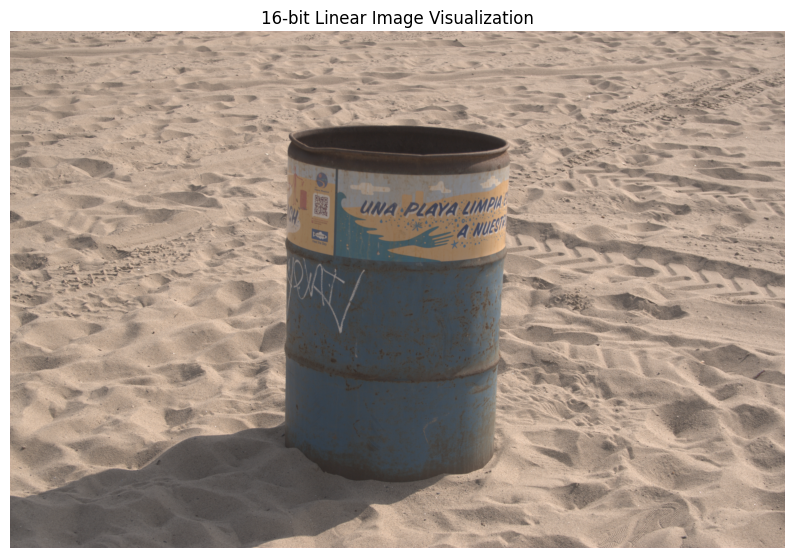

In [9]:
show_linear_image(ds[img_idx])